In [1]:
from pyspark.sql import functions as F

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MyApp") \
    .master("local[*]") \
    .getOrCreate()

In [3]:
volume_base = "/home/jovyan/work"

In [4]:
# GPS: 5000 rows in a box that overlaps both warehouse geofences
gps_path = f"{volume_base}/gps"
df_gps = (
    spark.range(0, 5000)
    .repartition(10)
    .select(
        F.format_string("device_%d", F.col("id").cast("long")).alias("device_id"),
        F.current_timestamp().alias("timestamp"),
        (-118.3 + F.rand() * 0.2).alias("longitude"),   # -118.3 to -118.1
        (34.0 + F.rand() * 0.2).alias("latitude"),     # 34.0 to 34.2
    )
)
df_gps.write.format("json").mode("overwrite").save(gps_path)
print(f"Wrote 5000 GPS rows to {gps_path}")

Wrote 5000 GPS rows to /home/jovyan/work/gps


In [5]:
df_gps.show()
df_gps.printSchema()

+----------+--------------------+-------------------+------------------+
| device_id|           timestamp|          longitude|          latitude|
+----------+--------------------+-------------------+------------------+
|device_303|2026-03-31 12:49:...|-118.13878287502034| 34.19876202517414|
|device_460|2026-03-31 12:49:...|-118.21543296495997|34.102550555672316|
|device_131|2026-03-31 12:49:...|-118.15994947017936|34.119628011126814|
|device_202|2026-03-31 12:49:...|-118.19684493693353| 34.04708420695789|
| device_52|2026-03-31 12:49:...|-118.14839779648598| 34.01817254345281|
|device_465|2026-03-31 12:49:...|-118.20988395409347| 34.19557628388636|
|device_177|2026-03-31 12:49:...|-118.25022580288635| 34.19711733131472|
| device_22|2026-03-31 12:49:...|-118.17823649862379|34.150985208493104|
|device_243|2026-03-31 12:49:...|-118.11463296289624|  34.0512263656899|
| device_20|2026-03-31 12:49:...|-118.26996660983303| 34.04208935100754|
| device_97|2026-03-31 12:49:...|-118.1612540268109

In [6]:
# Geofences: two warehouse polygons (WKT) in the same region
geofences_path = f"{volume_base}/geofences"
geofences_data = [
    ("Warehouse_A", "POLYGON ((-118.35 34.02, -118.25 34.02, -118.25 34.08, -118.35 34.08, -118.35 34.02))"),
    ("Warehouse_B", "POLYGON ((-118.20 34.05, -118.12 34.05, -118.12 34.12, -118.20 34.12, -118.20 34.05))"),
]
df_geo = spark.createDataFrame(geofences_data, ["warehouse_name", "boundary_wkt"])
df_geo.write.format("json").mode("overwrite").save(geofences_path)
print(f"Wrote {len(geofences_data)} geofences to {geofences_path}")

Wrote 2 geofences to /home/jovyan/work/geofences


In [7]:
df_geo.show()
df_geo.printSchema()

+--------------+--------------------+
|warehouse_name|        boundary_wkt|
+--------------+--------------------+
|   Warehouse_A|POLYGON ((-118.35...|
|   Warehouse_B|POLYGON ((-118.20...|
+--------------+--------------------+

root
 |-- warehouse_name: string (nullable = true)
 |-- boundary_wkt: string (nullable = true)



In [11]:
df_gps.show()

+----------+--------------------+-------------------+------------------+
| device_id|           timestamp|          longitude|          latitude|
+----------+--------------------+-------------------+------------------+
|device_303|2026-03-31 12:53:...|-118.13878287502034| 34.19876202517414|
|device_460|2026-03-31 12:53:...|-118.21543296495997|34.102550555672316|
|device_131|2026-03-31 12:53:...|-118.15994947017936|34.119628011126814|
|device_202|2026-03-31 12:53:...|-118.19684493693353| 34.04708420695789|
| device_52|2026-03-31 12:53:...|-118.14839779648598| 34.01817254345281|
|device_465|2026-03-31 12:53:...|-118.20988395409347| 34.19557628388636|
|device_177|2026-03-31 12:53:...|-118.25022580288635| 34.19711733131472|
| device_22|2026-03-31 12:53:...|-118.17823649862379|34.150985208493104|
|device_243|2026-03-31 12:53:...|-118.11463296289624|  34.0512263656899|
| device_20|2026-03-31 12:53:...|-118.26996660983303| 34.04208935100754|
| device_97|2026-03-31 12:53:...|-118.1612540268109

In [16]:
# Convert dataframe to RDD dataframe
data_frame_rdd=df_gps.rdd
# Show partitions on pyspark RDD using
# getNumPartitions function
print(data_frame_rdd.getNumPartitions())

10


In [21]:
import pandas as pd
from shapely.geometry import Point
from pyspark.sql.types import StructType, StructField, StringType, DoubleType
from pyspark.sql.functions import col, to_timestamp

def process_partition(iterator):
    rows = list(iterator)
    if not rows:
        return iter([])
    pdf = pd.DataFrame.from_records(rows, columns=["device_id", "timestamp", "longitude", "latitude"])
    pdf["longitude"] = pd.to_numeric(pdf["longitude"], errors="coerce")
    pdf["latitude"] = pd.to_numeric(pdf["latitude"], errors="coerce")
    pdf = pdf.dropna(subset=["longitude", "latitude"])
    if pdf.empty:
        return iter([])
    pdf["geometry"] = [Point(lon, lat).wkt for lon, lat in zip(pdf["longitude"], pdf["latitude"])]
    pdf["timestamp"] = pdf["timestamp"].astype(str)  # avoid Timestamp pickle error
    return iter(pdf[["device_id", "longitude", "latitude", "timestamp", "geometry"]].to_dict("records"))

output_schema = StructType([
    StructField("device_id", StringType(), True),
    StructField("longitude", DoubleType(), True),
    StructField("latitude", DoubleType(), True),
    StructField("timestamp", StringType(), True),
    StructField("geometry", StringType(), True),
])

gps_geometry_path = f"{volume_base}/geo_point"
rdd_result = df_gps.rdd.mapPartitions(process_partition)
df_result = spark.createDataFrame(rdd_result, schema=output_schema)
df_result = df_result.withColumn("timestamp", to_timestamp(col("timestamp")))
df_result.write.mode("overwrite").parquet(gps_geometry_path)
df_result.show()

In [38]:
from pyspark.sql.functions import udf
from pyspark.sql.types import BooleanType
from shapely import wkt

warehouses = df_geo.collect()
warehouse_polygons = {row.warehouse_name: wkt.loads(row.boundary_wkt) for row in warehouses}

# Broadcast the polygons dict to all workers
bc_polygons = spark.sparkContext.broadcast(warehouse_polygons)

def point_in_warehouse(geometry_wkt, warehouse_name):
    from shapely import wkt as shapely_wkt
    if geometry_wkt is None:
        return False
    point = shapely_wkt.loads(geometry_wkt)
    polygon = bc_polygons.value.get(warehouse_name)
    return polygon.contains(point) if polygon else False

in_warehouse_a = udf(lambda g: point_in_warehouse(g, "Warehouse_A"), BooleanType())
in_warehouse_b = udf(lambda g: point_in_warehouse(g, "Warehouse_B"), BooleanType())

df_merge = (
    df_result
    .withColumn("Warehouse_A", in_warehouse_a("geometry"))
    .withColumn("Warehouse_B", in_warehouse_b("geometry"))
)
df_merge.show()

+----------+-------------------+------------------+--------------------+--------------------+-----------+-----------+
| device_id|          longitude|          latitude|           timestamp|            geometry|Warehouse_A|Warehouse_B|
+----------+-------------------+------------------+--------------------+--------------------+-----------+-----------+
|device_303|-118.13878287502034| 34.19876202517414|2026-03-31 12:49:...|POINT (-118.13878...|      false|      false|
|device_460|-118.21543296495997|34.102550555672316|2026-03-31 12:49:...|POINT (-118.21543...|      false|      false|
|device_131|-118.15994947017936|34.119628011126814|2026-03-31 12:49:...|POINT (-118.15994...|      false|       true|
|device_202|-118.19684493693353| 34.04708420695789|2026-03-31 12:49:...|POINT (-118.19684...|      false|      false|
| device_52|-118.14839779648598| 34.01817254345281|2026-03-31 12:49:...|POINT (-118.14839...|      false|      false|
|device_465|-118.20988395409347| 34.19557628388636|2026-

In [62]:
# point in warehouse A
points_warehouse_A = df_merge.filter("Warehouse_A = true").select("device_id", "timestamp", "longitude", "latitude").toPandas()
points_warehouse_A.head()

,device_id,timestamp,longitude,latitude
0,device_20,2026-03-31 12:49:21.660468,-118.269967,34.042089
1,device_362,2026-03-31 12:49:21.660468,-118.292200,34.027568
2,device_907,2026-03-31 12:49:21.660468,-118.259783,34.044639
3,device_895,2026-03-31 12:49:21.660468,-118.286978,34.040492
4,device_969,2026-03-31 12:49:21.660468,-118.291008,34.052801


In [63]:
# point in warehouse B
points_warehouse_B = df_merge.filter("Warehouse_B = true").select("device_id", "timestamp", "longitude", "latitude").toPandas()
points_warehouse_B.head()

,device_id,timestamp,longitude,latitude
0,device_131,2026-03-31 12:49:21.660468,-118.159949,34.119628
1,device_33,2026-03-31 12:49:21.660468,-118.151142,34.056114
2,device_112,2026-03-31 12:49:21.660468,-118.125564,34.084969
3,device_401,2026-03-31 12:49:21.660468,-118.155864,34.111182
4,device_351,2026-03-31 12:49:21.660468,-118.167837,34.060447


In [79]:
import geopandas as gpd

gdf_points_A = gpd.GeoDataFrame(
    points_warehouse_A, geometry=gpd.points_from_xy(points_warehouse_A.longitude, points_warehouse_A.latitude), crs="EPSG:4326"
)

gdf_points_B = gpd.GeoDataFrame(
    points_warehouse_B, geometry=gpd.points_from_xy(points_warehouse_B.longitude, points_warehouse_B.latitude), crs="EPSG:4326"
)


In [86]:
from shapely.wkt import loads

df_warehouses = df_geo.toPandas()

df_warehouses["geometry"] = df_warehouses["boundary_wkt"].apply(loads)

gdf_warehouses = gpd.GeoDataFrame(df_warehouses, geometry="geometry", crs="EPSG:4326")


<Axes: >

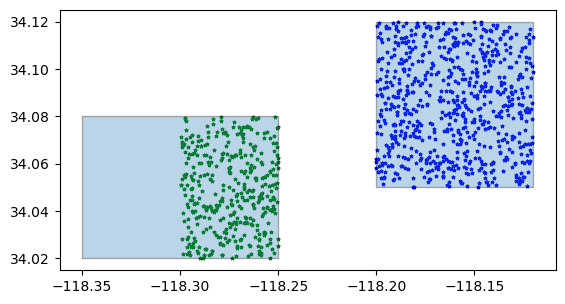

In [85]:
ax = gdf_points_A.plot(marker='*', color='green', markersize=5);

gdf_points_B.plot(marker='*', color='blue', markersize=5, ax=ax);

gdf_warehouses.plot(ax=ax, 
                    alpha=0.3,
                    edgecolor="black"
                   )